<a href="https://colab.research.google.com/github/reddolivia/data-science-practice/blob/main/intoLeNetCIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# LeNet - CIFAR10 - DeepLearning

In [2]:
"""
Meta-data of the dataset
tihs is a 500000 32x32 color training images and 10000 test images, labels
Each training & test examples is assigned to one of the following classes:
        airplane
        automobile
        bird
        cat
        deer
        dog
        frog
        horse
        ship
        truck
"""

'\nMeta-data of the dataset\ntihs is a 500000 32x32 color training images and 10000 test images, labels\nEach training & test examples is assigned to one of the following classes:\n        airplane\n        automobile\n        bird\n        cat\n        deer\n        dog\n        frog\n        horse\n        ship\n        truck\n'

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


In [4]:
# Downloading the dataset
cifar10 = tf.keras.datasets.cifar10
(xtrain , ytrain), (xtest, ytest) = cifar10.load_data()

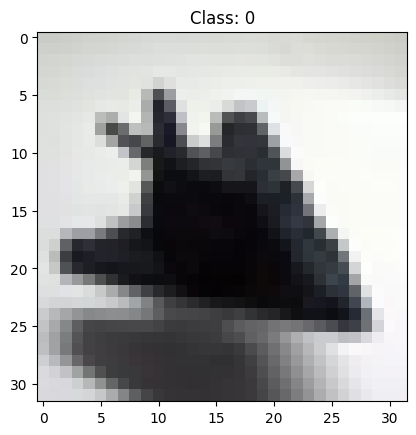

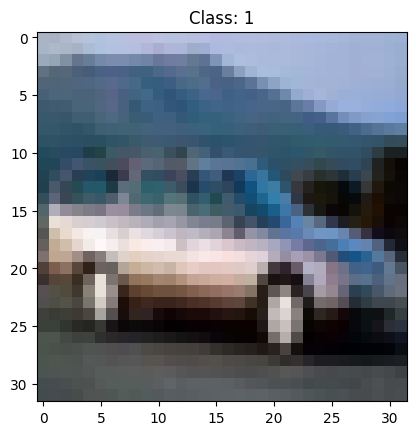

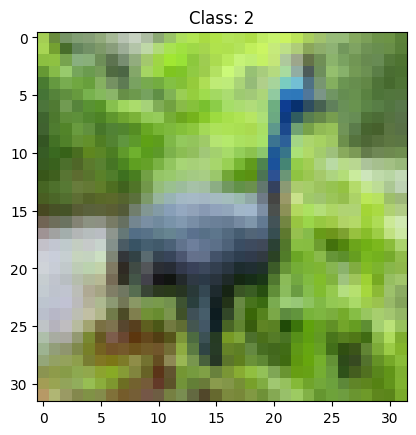

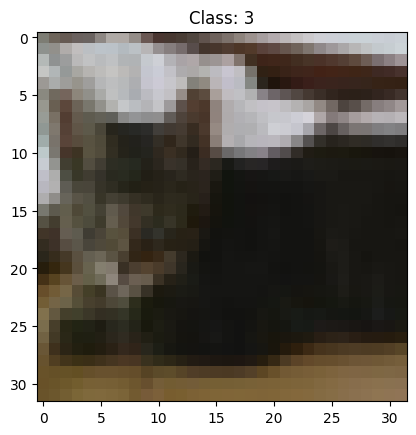

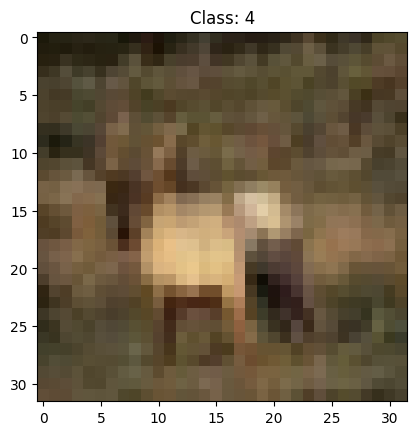

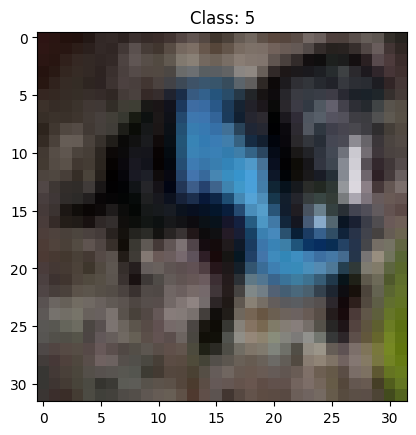

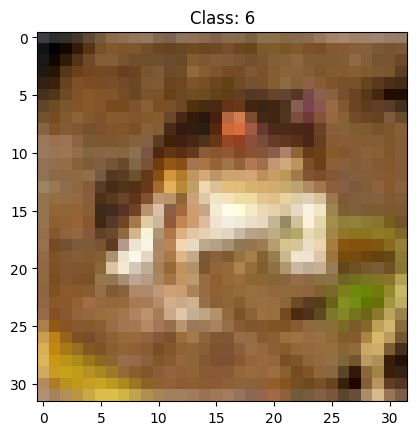

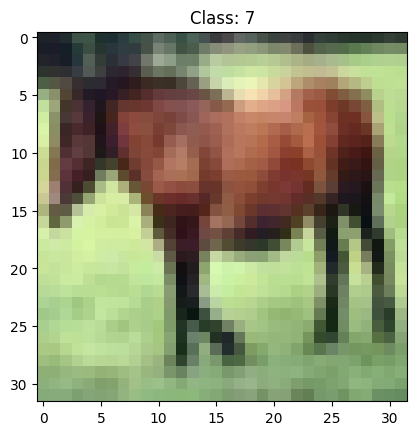

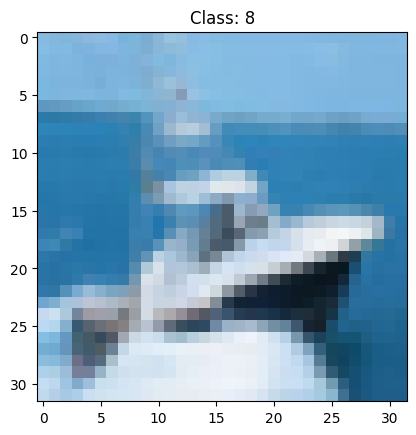

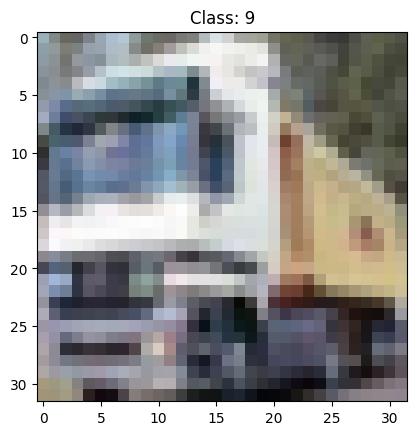

In [5]:
# printing an image from each class
for i in range(0,10):
  plt.figure(i)
  plt.title(str.format('Class: {}', i))
  im = plt.imshow(xtrain[np.where(ytrain==i)[0][0]])

In [6]:
#  1. Normalize data

xtrain_norm = xtrain / 255
xtest_norm = xtest / 255

# 2. Define Data Augmentation function
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_crop(image, size = [32,32,3])
    return image, label

# 3. Create train dataloader
train_dataset = tf.data.Dataset.from_tensor_slices((xtrain_norm, ytrain))
train_dataset = (
    train_dataset
    .shuffle(buffer_size = 50000)
    .map(augment, num_parallel_calls = tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

# 4. Create test dataloader
test_dataset = (
    tf.data.Dataset.from_tensor_slices((xtest_norm, ytest))
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)


**LeNet-5**

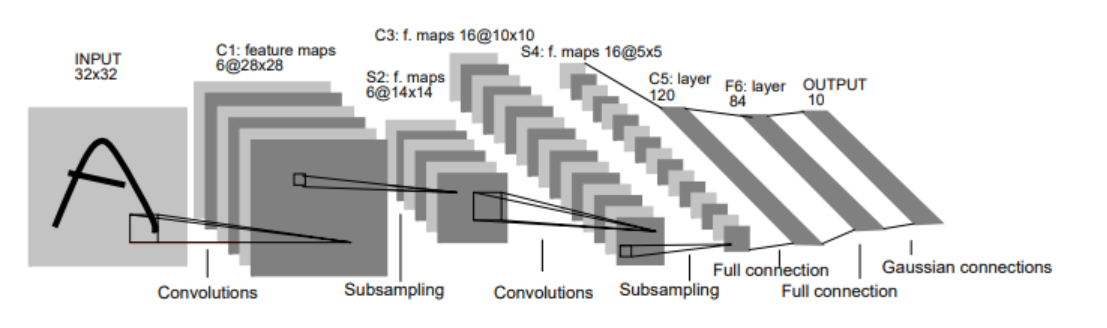

In [7]:
from keras.src import metrics
#  ---------------BUILDING MODEL------------

from keras import layers, models

# 1. Data Augmentation in model
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1)
])

# 2. LeNet Model
model = models.Sequential([
            layers.Input((32,32,3)),

            # Apply Augmentation irectly insde the model
            data_augmentation,

            # Rescale pixels values [0, 255] -> [0,1]
            #layers.Rescaling(1./255),

            # conv1: Block1 -> f32 ->  Relu ->  BatchNormalization
            layers.Conv2D(filters = 32,kernel_size = (3,3), padding = 'same', activation = 'relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(pool_size = (2,2)),


            # Conv2: Block2 -> f64 -> ReLU -> BatchNormalization
            layers.Conv2D(filters = 64, kernel_size = (3,3), padding = 'same', activation = 'relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size = (2,2)),


            # Dense / Fullt connected Layers
            layers.Flatten(),
            layers.Dense(128, activation = 'relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.5),                # prevents overfitting
            layers.Dense(10, activation = 'softmax')

        ])


In [8]:
# Compile the model

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'])

history = model.fit(
    train_dataset,
    epochs = 12,
    validation_data = test_dataset
)

Epoch 1/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - accuracy: 0.4380 - loss: 1.6302 - val_accuracy: 0.5002 - val_loss: 1.4340
Epoch 2/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.5584 - loss: 1.2513 - val_accuracy: 0.5034 - val_loss: 1.5762
Epoch 3/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.5886 - loss: 1.1678 - val_accuracy: 0.5648 - val_loss: 1.2904
Epoch 4/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.6146 - loss: 1.1043 - val_accuracy: 0.6261 - val_loss: 1.1219
Epoch 5/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.6320 - loss: 1.0549 - val_accuracy: 0.6293 - val_loss: 1.0966
Epoch 6/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6452 - loss: 1.0190 - val_accuracy: 0.6390 - val_loss: 1.0565
Epoch 7/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6549 - loss: 0.9943 - val_accuracy: 0.6895 - val_loss: 0.9094
Epoch 8/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6645 -

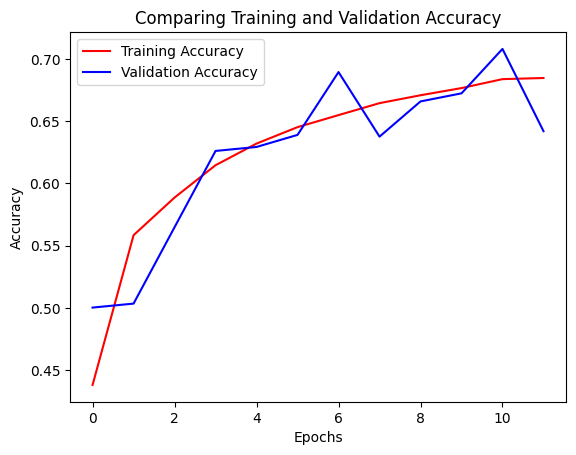

In [9]:
# Etracting models accuracy against epochs

ta = history.history['accuracy']
va = history.history['val_accuracy']
epochs  = range(len(ta))

# plotting the accuracies
plt.figure()
plt.plot(epochs, ta, 'r', label = 'Training Accuracy')
plt.plot(epochs, va, 'b', label = 'Validation Accuracy')
plt.title('Comparing Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

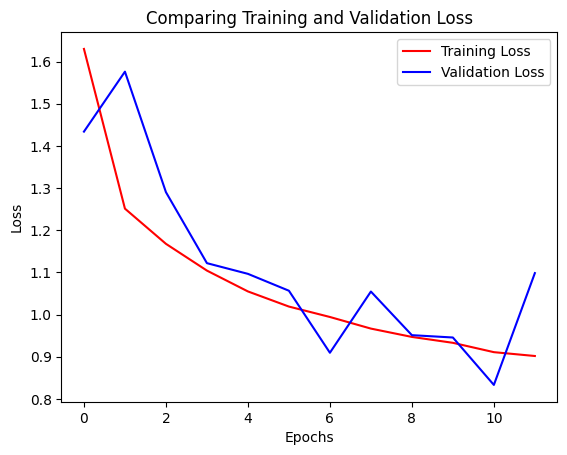

In [10]:
# Etracting models loss against epochs

tl = history.history['loss']
vl = history.history['val_loss']
epochs  = range(len(tl))

# plotting the accuracies
plt.figure()
plt.plot(epochs, tl, 'r', label = 'Training Loss')
plt.plot(epochs, vl, 'b', label = 'Validation Loss')
plt.title('Comparing Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [11]:
# obtaining the predictions
pred = np.argmax(model.predict(xtest), axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [12]:
# Evaluate using test_dataset
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Accuracy on Test Set: {test_acc * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6420 - loss: 1.0984
Accuracy on Test Set: 64.20%


In [13]:
# priting the clasification report
from sklearn.metrics import classification_report
print(classification_report(ytest, pred))

              precision    recall  f1-score   support

           0       0.40      0.46      0.43      1000
           1       0.24      0.94      0.39      1000
           2       0.72      0.04      0.08      1000
           3       0.67      0.01      0.02      1000
           4       0.00      0.00      0.00      1000
           5       0.46      0.39      0.42      1000
           6       0.76      0.22      0.35      1000
           7       0.76      0.39      0.51      1000
           8       0.25      0.72      0.37      1000
           9       0.77      0.28      0.41      1000

    accuracy                           0.34     10000
   macro avg       0.50      0.34      0.30     10000
weighted avg       0.50      0.34      0.30     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


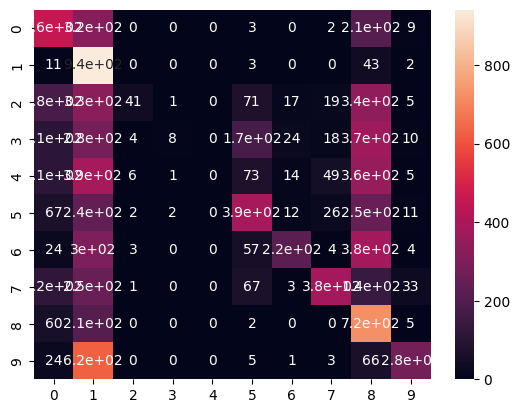

In [14]:
# plotting the confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(ytest, pred), annot = True)
plt.show()